## Notebook 4 — EDA (the detailed one)
- Work on the training split only — do not open the test set
- Data types, shape, and memory: what is numerical, categorical, date, text, ID
- Missing values: how many, where, and is the missing itself meaningful
- Numerical: statistics, distributions, skew, outliers, ranges that make no sense
- Categorical: value counts, cardinality, rare categories, messy or duplicated values
- Relations: groupby against the label, correlations, cross-tabs, charts
- Dates: order dates, delivery times, seasonality, weekday and holiday effects
- Geography: customer and seller state, distance, ZIP-code prefix
- Write down what you find — the goal is to decide your features and your model
- Artifact: saved charts and a short findings summary

In [ ]:
import pandas as pd
import tracemalloc

tracemalloc.start()
TrainingData = pd.read_parquet("../artifacts/ml_table_train.parquet")
print("Training Data loaded successfully! Shape:", TrainingData.shape)
print("___________________________________________")
print("Memory Usage:")
current, peak = tracemalloc.get_traced_memory()

print(f"Current memory: {current / (1024 * 1024):.2f} MB")
print(f"Peak memory: {peak / (1024 * 1024):.2f} MB")
tracemalloc.stop()


Training Data loaded successfully! Shape: (69608, 41)
___________________________________________
Memory Usage:
Current memory: 1.28 MB
Peak memory: 14.23 MB


In [42]:
print("=" * 50)
print("2. DATA TYPES CATEGORIZATION")
print("=" * 50)

type_groups = {
    'IDs': [col for col in TrainingData.columns if 'id' in col.lower() or 'zip' in col.lower()],
    'string / object': TrainingData.select_dtypes(include=['object', 'string']).columns.tolist(),
    'integer': TrainingData.select_dtypes(include=['int64']).columns.tolist(),
    'float': TrainingData.select_dtypes(include=['float64']).columns.tolist(),
    'date / datetime': TrainingData.select_dtypes(include=['datetime64', '<M']).columns.tolist()
}

for data_type, cols in type_groups.items():
    if cols:
        print(f"=== {data_type} ({len(cols)} columns) ===")
        for col in cols:
            print(f"  - {col}")
        print()


print("=" * 50)
print("3. MISSING VALUES ANALYSIS")
print("=" * 50)

missing_count = TrainingData.isnull().sum()
missing_percentage = (TrainingData.isnull().sum() / len(TrainingData)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percentage
})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False)
print(missing_df)

2. DATA TYPES CATEGORIZATION
=== IDs (7 columns) ===
  - order_id
  - customer_id
  - customer_unique_id
  - customer_zip_code_prefix
  - product_width_cm
  - sellers_zip_codes_combined
  - primary_seller_zip

=== string / object (14 columns) ===
  - order_id
  - customer_id
  - order_status
  - customer_unique_id
  - customer_zip_code_prefix
  - customer_city
  - customer_state
  - combined_review_comments
  - payment_type
  - primary_product_category
  - sellers_zip_codes_combined
  - sellers_cities_combined
  - sellers_states_combined
  - primary_seller_zip

=== integer (1 columns) ===
  - is_late

=== float (19 columns) ===
  - avg_review_score
  - review_count
  - payment_value
  - payment_count
  - max_payment_installments
  - total_items_count
  - total_items_price
  - total_freight_value
  - total_product_weight_g
  - product_length_cm
  - product_height_cm
  - product_width_cm
  - total_product_photos
  - total_unique_sellers
  - customer_lat
  - customer_lng
  - seller_lat
  

In [ ]:

numerical_cols = TrainingData.select_dtypes(include=['int64', 'float64']).columns

print("=" * 50)
print("1. DESCRIPTIVE STATISTICS")
print("=" * 50)
display(TrainingData[numerical_cols].describe())

print("\n" + "=" * 50)
print("2. SKEWNESS (Distribution Asymmetry)")
print("=" * 50)
skewness_values = TrainingData[numerical_cols].skew()
print(skewness_values)

1. DESCRIPTIVE STATISTICS


,avg_review_score,review_count,payment_value,payment_count,max_payment_installments,total_items_count,total_items_price,total_freight_value,total_product_weight_g,product_length_cm,product_height_cm,product_width_cm,total_product_photos,total_unique_sellers,customer_lat,customer_lng,seller_lat,seller_lng,distance_km,is_late
count,69000.000000,69000.000000,69607.000000,69607.000000,69607.000000,68961.000000,68961.000000,68961.000000,68961.000000,68945.000000,68945.000000,68945.000000,68961.000000,68961.000000,69415.000000,69415.000000,44351.000000,44351.000000,44243.000000,69608.000000
mean,4.022314,1.007348,159.257369,1.048257,2.979499,1.141486,136.615566,22.288178,2466.514189,30.737486,16.835971,23.429502,2.467917,1.011746,-21.117069,-46.162451,-22.435663,-47.640168,650.343654,0.087404
std,1.385458,0.086081,216.625471,0.412692,2.759644,0.541285,206.374262,20.077747,4909.083787,16.524991,13.733732,12.092519,2.220316,0.113380,5.715484,4.121084,3.020521,2.847457,563.915444,0.282428
min,1.000000,1.000000,10.070000,1.000000,1.000000,1.000000,2.290000,0.000000,0.000000,7.000000,2.000000,6.000000,0.000000,1.000000,-33.689948,-72.668881,-32.079231,-67.813284,0.000000,0.000000
25%,4.000000,1.000000,61.720000,1.000000,1.000000,1.000000,45.900000,14.100000,300.000000,18.000000,8.000000,15.000000,1.000000,1.000000,-23.587566,-48.249267,-23.331337,-49.212436,297.265427,0.000000
50%,5.000000,1.000000,104.350000,1.000000,2.000000,1.000000,85.500000,16.790000,800.000000,25.000000,13.000000,20.000000,2.000000,1.000000,-22.915669,-46.623872,-22.600004,-47.823700,490.282412,0.000000
75%,5.000000,1.000000,175.870000,1.000000,4.000000,1.000000,149.900000,23.700000,2150.000000,40.000000,20.000000,30.000000,3.000000,1.000000,-19.992000,-43.507047,-21.254548,-46.478237,828.517217,0.000000
max,5.000000,3.000000,13664.080000,29.000000,24.000000,21.000000,13440.000000,1002.290000,184400.000000,105.000000,105.000000,118.000000,62.000000,5.000000,22.567952,-23.583939,-2.501242,-34.855616,5335.267696,1.000000



2. SKEWNESS (Distribution Asymmetry)
avg_review_score            -1.259479
review_count                11.808841
payment_value                9.843399
payment_count               24.416209
max_payment_installments     1.584223
total_items_count            8.073434
total_items_price           10.491206
total_freight_value          8.496228
total_product_weight_g       6.600061
product_length_cm            1.725330
product_height_cm            2.209106
product_width_cm             1.728510
total_product_photos         3.645502
total_unique_sellers        10.672394
customer_lat                 1.581224
customer_lng                -0.032557
seller_lat                   1.404565
seller_lng                   0.772959
distance_km                  1.711301
is_late                      2.921866
dtype: float64


In [ ]:
categorical_cols = TrainingData.select_dtypes(include=['object', 'string']).columns

print("=" * 60)
print("CATEGORICAL FEATURES CARDINALITY & TOP VALUES")
print("=" * 60)

for col in categorical_cols:
    unique_count = TrainingData[col].nunique()
    print(f"\nColumn: **{col}** | Unique Values (Cardinality): {unique_count}")

    print("Top 5 frequent values:")
    print(TrainingData[col].value_counts().head(5))
    print("-" * 40)

CATEGORICAL FEATURES CARDINALITY & TOP VALUES

Column: **order_id** | Unique Values (Cardinality): 69608
Top 5 frequent values:
order_id
2e7a8482f6fb09756ca50c10d7bfc047    1
e5fa5a7210941f7d56d0208e4e071d35    1
809a282bbd5dbcabb6f2f724fca862ec    1
bfbd0f9bdef84302105ad712db648a6c    1
71303d7e93b399f5bcd537d124c0bcfa    1
Name: count, dtype: int64
----------------------------------------

Column: **customer_id** | Unique Values (Cardinality): 69608
Top 5 frequent values:
customer_id
08c5351a6aca1c1589a38f244edeee9d    1
683c54fc24d40ee9f8a6fc179fd9856c    1
622e13439d6b5a0b486c435618b2679e    1
86dc2ffce2dfff336de2f386a786e574    1
b106b360fe2ef8849fbbd056f777b4d5    1
Name: count, dtype: int64
----------------------------------------

Column: **order_status** | Unique Values (Cardinality): 8
Top 5 frequent values:
order_status
delivered      67224
shipped          855
unavailable      561
canceled         429
processing       290
Name: count, dtype: int64
--------------------------

1. NUMERICAL CORRELATIONS WITH 'is_late'
is_late                     1.000000
distance_km                 0.083333
customer_lng                0.080387
customer_lat                0.059961
total_freight_value         0.045235
seller_lat                  0.027804
payment_value               0.022657
total_items_price           0.019982
total_product_weight_g      0.019185
product_length_cm           0.018177
max_payment_installments    0.016106
product_height_cm           0.012123
product_width_cm            0.007759
review_count               -0.004018
seller_lng                 -0.005060
payment_count              -0.005984
total_product_photos       -0.011717
total_items_count          -0.015567
total_unique_sellers       -0.025010
avg_review_score           -0.361697
Name: is_late, dtype: float64

2. CATEGORICAL RELATIONS (Groupby payment_type vs is_late)
payment_type
debit_card              9.623431
boleto                  9.092809
credit_card             8.701706
voucher, credit_c

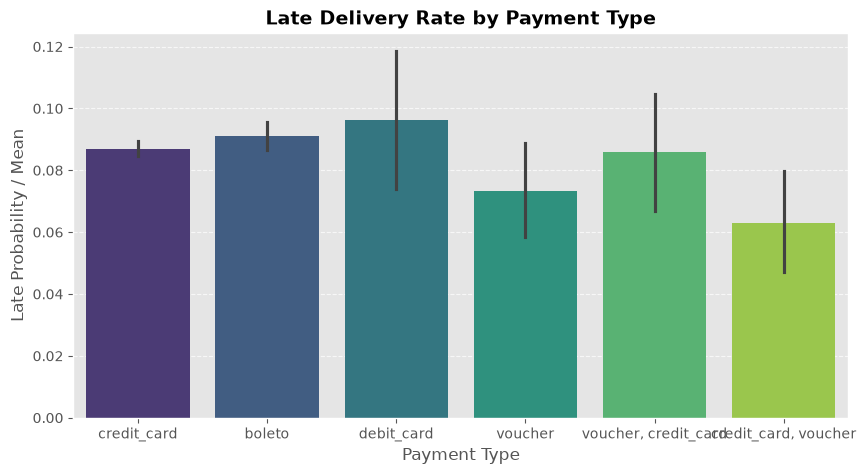

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("1. NUMERICAL CORRELATIONS WITH 'is_late'")
print("=" * 60)

numerical_cols = TrainingData.select_dtypes(include=['int64', 'float64']).columns
correlations = TrainingData[numerical_cols].corr()['is_late'].sort_values(ascending=False)
print(correlations)

print("\n" + "=" * 60)
print("2. CATEGORICAL RELATIONS (Groupby payment_type vs is_late)")
print("=" * 60)

if 'payment_type' in TrainingData.columns:
    payment_delay = TrainingData.groupby('payment_type')['is_late'].mean() * 100
    print(payment_delay.sort_values(ascending=False))

print("\n" + "=" * 60)
print("3. VISUALIZING A RELATIONSHIP (Chart)")
print("=" * 60)

plt.figure(figsize=(10, 5))
if 'payment_type' in TrainingData.columns:
    sns.barplot(x=TrainingData['payment_type'], y=TrainingData['is_late'], hue=TrainingData['payment_type'], palette='viridis', legend=False)
    plt.title("Late Delivery Rate by Payment Type", fontsize=14, fontweight='bold')
    plt.xlabel("Payment Type", fontsize=12)
    plt.ylabel("Late Probability / Mean", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

- distance_km                 0.083333


1. LATE DELIVERY RATE BY WEEKDAY
order_weekday
Monday       9.673649
Tuesday      8.971929
Wednesday    8.299916
Thursday     8.001931
Friday       9.137948
Saturday     8.733964
Sunday       8.190841
Name: is_late, dtype: float64

2. VISUALIZING LATE RATE BY WEEKDAY


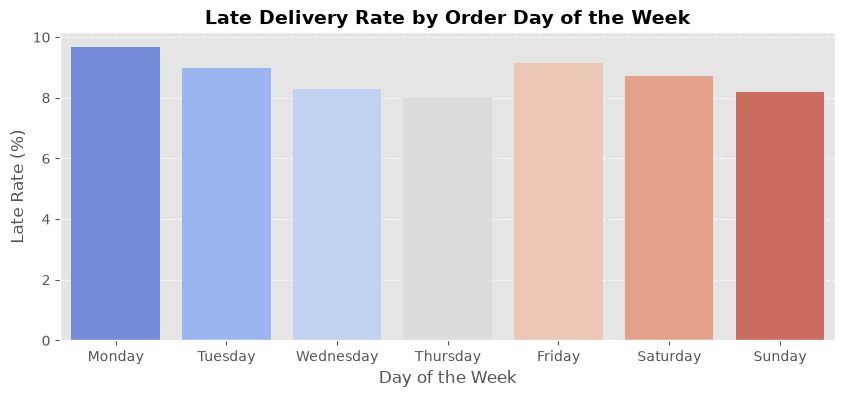

In [ ]:
date_col = 'order_purchase_timestamp'

if date_col in TrainingData.columns:
    TrainingData[date_col] = pd.to_datetime(TrainingData[date_col])
    

    TrainingData['order_weekday'] = TrainingData[date_col].dt.day_name()
    TrainingData['order_month'] = TrainingData[date_col].dt.month_name()
    TrainingData['order_hour'] = TrainingData[date_col].dt.hour

    print("=" * 60)
    print("1. LATE DELIVERY RATE BY WEEKDAY")
    print("=" * 60)
  
    weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    weekday_delay = TrainingData.groupby('order_weekday')['is_late'].mean() * 100
    print(weekday_delay.reindex(weekday_order))

    print("\n" + "=" * 60)
    print("2. VISUALIZING LATE RATE BY WEEKDAY")
    print("=" * 60)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=weekday_delay.reindex(weekday_order).index, y=weekday_delay.reindex(weekday_order).values, palette='coolwarm', hue=weekday_delay.reindex(weekday_order).index, legend=False)
    plt.title("Late Delivery Rate by Order Day of the Week", fontsize=14, fontweight='bold')
    plt.xlabel("Day of the Week", fontsize=12)
    plt.ylabel("Late Rate (%)", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

1. LATE DELIVERY RATE BY CUSTOMER STATE
customer_state
AL    26.517572
MA    20.665499
CE    17.457114
SE    16.406250
PI    16.111111
RJ    15.883549
RR    14.705882
BA    14.375000
ES    12.942779
TO    12.935323
Name: is_late, dtype: float64

2. VISUALIZING LATE RATE BY TOP CUSTOMER STATES


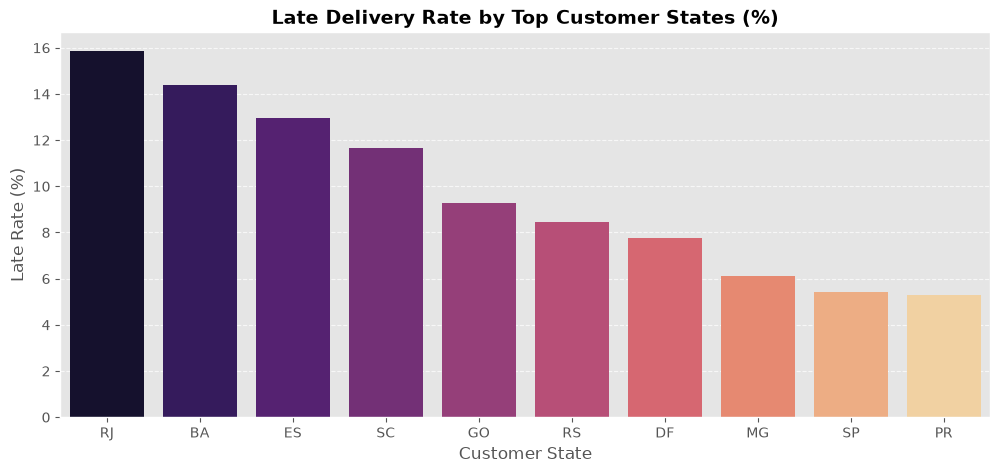

In [ ]:


print("=" * 60)
print("1. LATE DELIVERY RATE BY CUSTOMER STATE")
print("=" * 60)
if 'customer_state' in TrainingData.columns:
    cust_state_delay = (TrainingData.groupby('customer_state')['is_late'].mean() * 100).sort_values(ascending=False)
    print(cust_state_delay.head(10))

print("\n" + "=" * 60)
print("2. VISUALIZING LATE RATE BY TOP CUSTOMER STATES")
print("=" * 60)
plt.figure(figsize=(12, 5))
if 'customer_state' in TrainingData.columns:
    top_states = TrainingData['customer_state'].value_counts().head(10).index
    filtered_states_data = TrainingData[TrainingData['customer_state'].isin(top_states)]
    
    state_delay_plot = filtered_states_data.groupby('customer_state')['is_late'].mean().reset_index()
    state_delay_plot['is_late'] *= 100
    state_delay_plot = state_delay_plot.sort_values(by='is_late', ascending=False)
    
    sns.barplot(x='customer_state', y='is_late', data=state_delay_plot, palette='magma', hue='customer_state', legend=False)
    plt.title("Late Delivery Rate by Top Customer States (%)", fontsize=14, fontweight='bold')
    plt.xlabel("Customer State", fontsize=12)
    plt.ylabel("Late Rate (%)", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

### Key EDA Findings & Insights

* **Missing Values Analysis:** 
  The missing distance values are natural and logical, as they directly stem from missing seller coordinate data. Similarly, missing delivery dates indicate cancelled orders, which highlights the critical importance of our predictive model.

* **Numerical Features & Skewness:**
  * **Average Review Score:** Shows a negative skew because the vast majority of customers give 5-star ratings, pulling the distribution to the left.
  * **Review Count & Payment Count & Price:** Exhibit positive skews (right-tailed) due to a few high-value outliers pulling the data to the right.

* **Categorical Data & Messy Values:**
  * Text review comments have a very high cardinality (over 26,000 unique texts) and contain inconsistent casing (e.g., mixing uppercase and lowercase like "Bom" and "bom"), which requires standardization.

* **Relationships & Correlations:**
  * **Distance:** A positive correlation between distance and late deliveries, proving that longer distances increase delay probability.
  * **Reviews:** A strong negative correlation between average review scores and late deliveries, showing that delayed orders heavily suffer in ratings.